# 🎨 Computação Gráfica e Processamento de Imagens

`Programação` · **Engenharia da Computação** · `Python 3`

> **Imagem digital, transformações geométricas, render e filtros.**

Do pixel ao filtro: representação de imagens, transformações geométricas com matrizes homogêneas, convolução (blur/sobel) e histograma — tudo com NumPy.



## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF gerado abaixo).

### 🟢 IMAGEM DIGITAL & CORES

**Ideia:** Representar imagens como matrizes de pixels e entender resolução, profundidade e modelos de cor.

- Pixel: menor elemento da imagem digital
- Resolução: largura × altura; afeta detalhe
- Profundidade: b bits/pixel → 2^b níveis
- Imagem em cinza: 0 = preto, máximo = branco
- RGB: mistura aditiva para telas
- CMY/CMYK: mistura subtrativa para impressão
- HSV: matiz, saturação e valor; útil em segmentação
- Histograma: distribuição das intensidades da imagem

> 💡 **Dica:** Nem toda tarefa deve ser feita em RGB. Para brilho/contraste e limiarização, muitas vezes vale converter para escala de cinza ou HSV.

### 🟢 GEOMETRIA, TRANSFORMAÇÕES & PROJEÇÃO

**Ideia:** Modelar objetos e mover pontos usando transformações lineares e projeções 2D/3D.

- Translação: desloca por (t_x, t_y, t_z)
- Escala: altera tamanho por fatores s_x, s_y, s_z
- Rotação 2D: [x' y'] = R(θ)[x y]
- Homogêneas: permitem compor translação + rotação + escala
- Composição: T = T_n...T_2T_1
- Viewport: mapeia mundo → tela
- Projeção ortográfica: preserva paralelismo
- Perspectiva: objetos distantes parecem menores

> 💡 **Dica:** A ordem importa: rotacionar e depois transladar não gera o mesmo resultado que transladar e depois rotacionar.

### 🟢 RASTERIZAÇÃO, ILUMINAÇÃO & RENDER

**Ideia:** Converter primitivas geométricas em pixels e controlar a aparência visual de uma cena.

- Primitivas: ponto, linha, triângulo, polígono
- Rasterização: decide quais pixels serão ativados
- Interpolação: cor, profundidade e textura variam nos fragmentos
- Z-buffer: guarda profundidade visível por pixel
- Iluminação: ambiente + difusa + especular
- Textura: mapeia imagem sobre a superfície
- Aliasing: serrilhado em bordas e detalhes finos
- Antialiasing: suaviza serrilhado por amostragem/filtro

> 💡 **Dica:** Se a imagem parecer “serrilhada”, pense primeiro em resolução, amostragem e antialiasing antes de mexer no modelo geométrico.

### 🟢 FILTROS, SEGMENTAÇÃO & MORFOLOGIA

**Ideia:** Extrair informação, melhorar qualidade e separar regiões de interesse em imagens digitais.

- Convolução: saída = imagem * máscara/kernel
- Suavização: média e Gauss reduzem ruído
- Realce: Sobel/Laplaciano destacam bordas
- Limiarização: separa objeto e fundo por intensidade
- Equalização: redistribui histograma e melhora contraste
- Dilatação: expande regiões claras/objeto
- Erosão: reduz regiões claras/objeto
- Abertura/Fechamento: removem ruídos e fecham falhas

> 💡 **Dica:** Escolha o filtro conforme o objetivo: suavizar para reduzir ruído, derivadas para bordas e morfologia para refinar a segmentação.


## ⚙️ Gerador do Cheat Sheet (PDF)

O script original gera um **PDF estilo OneNote** com `reportlab`. Para rodar em qualquer sistema operacional, as fontes são resolvidas automaticamente (usa a **DejaVu embarcada no matplotlib** com fallback para os caminhos clássicos de Windows/Linux/macOS) e o arquivo de saída é gerado na pasta atual.


In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path

from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Computacao_Grafica_Processamento_Imagens.pdf')
PAGE_W, PAGE_H = landscape(A4)
MARGIN = 16

# ---------- fonts ----------
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR / 'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR / 'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR / 'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFontFamily(
    'DVCond',
    normal='DVCond',
    bold='DVCond-Bold',
    italic='DVCond-Oblique',
    boldItalic='DVCond-Bold',
)

# ---------- palette ----------
BG = HexColor('#F6F8FB')
GRID = HexColor('#E6EBF3')
INK = HexColor('#1C2B4A')
MUTED = HexColor('#5A6B8C')
WHITE = HexColor('#FFFFFF')
LINE = HexColor('#E7ECF4')
AXIS = HexColor('#D7DEEA')

TEAL, TEAL_T = HexColor('#147D82'), HexColor('#E3F2F1')
AMBER, AMBER_T = HexColor('#C97A1A'), HexColor('#FBEDDD')
BERRY, BERRY_T = HexColor('#A83E63'), HexColor('#F6E4EB')
GREEN, GREEN_T = HexColor('#2F7A4F'), HexColor('#E2F0E7')

CARDS = [
    {
        'title': 'IMAGEM DIGITAL<br/>&amp; CORES',
        'color': TEAL,
        'tint': TEAL_T,
        'kind': 'imagem',
        'idea': 'Representar imagens como matrizes de pixels e entender resolução, profundidade e modelos de cor.',
        'formulas': [
            '<b>Pixel:</b> menor elemento da imagem digital',
            '<b>Resolução:</b> largura × altura; afeta detalhe',
            '<b>Profundidade:</b> b bits/pixel → 2<super>b</super> níveis',
            '<b>Imagem em cinza:</b> 0 = preto, máximo = branco',
            '<b>RGB:</b> mistura aditiva para telas',
            '<b>CMY/CMYK:</b> mistura subtrativa para impressão',
            '<b>HSV:</b> matiz, saturação e valor; útil em segmentação',
            '<b>Histograma:</b> distribuição das intensidades da imagem',
        ],
        'tip': 'Nem toda tarefa deve ser feita em RGB. Para brilho/contraste e limiarização, muitas vezes vale converter para escala de cinza ou HSV.',
    },
    {
        'title': 'GEOMETRIA,<br/>TRANSFORMAÇÕES &amp; PROJEÇÃO',
        'color': AMBER,
        'tint': AMBER_T,
        'kind': 'transformacoes',
        'idea': 'Modelar objetos e mover pontos usando transformações lineares e projeções 2D/3D.',
        'formulas': [
            '<b>Translação:</b> desloca por (t<sub>x</sub>, t<sub>y</sub>, t<sub>z</sub>)',
            '<b>Escala:</b> altera tamanho por fatores s<sub>x</sub>, s<sub>y</sub>, s<sub>z</sub>',
            '<b>Rotação 2D:</b> [x\' y\'] = R(θ)[x y]',
            '<b>Homogêneas:</b> permitem compor translação + rotação + escala',
            '<b>Composição:</b> T = T<sub>n</sub>...T<sub>2</sub>T<sub>1</sub>',
            '<b>Viewport:</b> mapeia mundo → tela',
            '<b>Projeção ortográfica:</b> preserva paralelismo',
            '<b>Perspectiva:</b> objetos distantes parecem menores',
        ],
        'tip': 'A ordem importa: rotacionar e depois transladar não gera o mesmo resultado que transladar e depois rotacionar.',
    },
    {
        'title': 'RASTERIZAÇÃO,<br/>ILUMINAÇÃO &amp; RENDER',
        'color': BERRY,
        'tint': BERRY_T,
        'kind': 'render',
        'idea': 'Converter primitivas geométricas em pixels e controlar a aparência visual de uma cena.',
        'formulas': [
            '<b>Primitivas:</b> ponto, linha, triângulo, polígono',
            '<b>Rasterização:</b> decide quais pixels serão ativados',
            '<b>Interpolação:</b> cor, profundidade e textura variam nos fragmentos',
            '<b>Z-buffer:</b> guarda profundidade visível por pixel',
            '<b>Iluminação:</b> ambiente + difusa + especular',
            '<b>Textura:</b> mapeia imagem sobre a superfície',
            '<b>Aliasing:</b> serrilhado em bordas e detalhes finos',
            '<b>Antialiasing:</b> suaviza serrilhado por amostragem/filtro',
        ],
        'tip': 'Se a imagem parecer “serrilhada”, pense primeiro em resolução, amostragem e antialiasing antes de mexer no modelo geométrico.',
    },
    {
        'title': 'FILTROS,<br/>SEGMENTAÇÃO &amp; MORFOLOGIA',
        'color': GREEN,
        'tint': GREEN_T,
        'kind': 'processamento',
        'idea': 'Extrair informação, melhorar qualidade e separar regiões de interesse em imagens digitais.',
        'formulas': [
            '<b>Convolução:</b> saída = imagem * máscara/kernel',
            '<b>Suavização:</b> média e Gauss reduzem ruído',
            '<b>Realce:</b> Sobel/Laplaciano destacam bordas',
            '<b>Limiarização:</b> separa objeto e fundo por intensidade',
            '<b>Equalização:</b> redistribui histograma e melhora contraste',
            '<b>Dilatação:</b> expande regiões claras/objeto',
            '<b>Erosão:</b> reduz regiões claras/objeto',
            '<b>Abertura/Fechamento:</b> removem ruídos e fecham falhas',
        ],
        'tip': 'Escolha o filtro conforme o objetivo: suavizar para reduzir ruído, derivadas para bordas e morfologia para refinar a segmentação.',
    },
]

# ---------- layout ----------
CARD_TOP = PAGE_H - 16
CARD_BOTTOM = 16
CARD_H = CARD_TOP - CARD_BOTTOM
GAP = 14
CARD_W = (PAGE_W - 2 * MARGIN - 3 * GAP) / 4

STYLE_TITLE = ParagraphStyle(
    'card_title', fontName='DVCond-Bold', fontSize=17.2, leading=18.6, textColor=WHITE, alignment=1
)
STYLE_IDEA = ParagraphStyle(
    'idea', fontName='DVCond-Oblique', fontSize=12.6, leading=15.6, textColor=MUTED
)
STYLE_TIP = ParagraphStyle(
    'tip', fontName='DVCond', fontSize=11.7, leading=14.7, textColor=INK
)


def arrow(c, x1, y1, x2, y2, color, width=1.1, head=4):
    c.setStrokeColor(color)
    c.setFillColor(color)
    c.setLineWidth(width)
    c.line(x1, y1, x2, y2)
    ang = math.atan2(y2 - y1, x2 - x1)
    for delta in (2.55, -2.55):
        c.line(x2, y2, x2 + head * math.cos(ang + delta), y2 + head * math.sin(ang + delta))


def box(c, x, y, w, h, color, label=None):
    c.setStrokeColor(color)
    c.setLineWidth(1.2)
    c.setFillColor(HexColor('#F8FAFD'))
    c.roundRect(x, y, w, h, 2, stroke=1, fill=1)
    if label:
        c.setFillColor(INK)
        c.setFont('DVCond-Bold', 8.4)
        c.drawCentredString(x + w/2, y + h/2 - 3, label)


def diagram_imagem(c, ox, oy, dw, dh, color):
    # pixel grid + RGB bars
    gx, gy = ox + dw*0.08, oy + dh*0.26
    size = 11
    for r in range(3):
        for col in range(4):
            c.setStrokeColor(color)
            c.setLineWidth(1.0)
            c.rect(gx + col*size, gy + r*size, size, size, stroke=1, fill=0)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 8.7)
    c.drawString(gx + 2, gy + 41, 'pixels')
    bx = ox + dw*0.55
    by = oy + dh*0.28
    for i,(lab,h) in enumerate([('R',26),('G',18),('B',34)]):
        c.setStrokeColor(color)
        c.rect(bx + i*14, by, 8, h, stroke=1, fill=0)
        c.setFillColor(INK)
        c.setFont('DVCond-Bold', 7.5)
        c.drawCentredString(bx + i*14 + 4, by + h + 8, lab)
    # histogram line
    c.setStrokeColor(AXIS)
    c.setLineWidth(0.8)
    hx, hy = ox + dw*0.52, oy + dh*0.12
    c.line(hx, hy, hx + 56, hy)
    c.line(hx, hy, hx, hy + 26)
    p = c.beginPath()
    pts = [(hx+2,hy+2),(hx+10,hy+6),(hx+18,hy+18),(hx+28,hy+10),(hx+38,hy+22),(hx+50,hy+5)]
    p.moveTo(*pts[0])
    for pt in pts[1:]: p.lineTo(*pt)
    c.setStrokeColor(color)
    c.drawPath(p, stroke=1, fill=0)


def diagram_transformacoes(c, ox, oy, dw, dh, color):
    # original and transformed square
    x, y = ox + dw*0.15, oy + dh*0.28
    c.setStrokeColor(color)
    c.setLineWidth(1.3)
    c.rect(x, y, 22, 22, stroke=1, fill=0)
    # rotated/scaled rectangle
    p = c.beginPath()
    pts = [(ox + dw*0.55, oy + dh*0.28), (ox + dw*0.68, oy + dh*0.37), (ox + dw*0.60, oy + dh*0.55), (ox + dw*0.47, oy + dh*0.46)]
    p.moveTo(*pts[0])
    for pt in pts[1:]: p.lineTo(*pt)
    p.close()
    c.drawPath(p, stroke=1, fill=0)
    arrow(c, x + 28, y + 12, ox + dw*0.44, oy + dh*0.39, color, 1.0, 4)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 9)
    c.drawCentredString(ox + dw*0.47, oy + dh*0.18, 'T · R · S')
    # viewport box
    c.setStrokeColor(AXIS)
    c.rect(ox + dw*0.73, oy + dh*0.20, 34, 28, stroke=1, fill=0)
    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 7.5)
    c.drawCentredString(ox + dw*0.73 + 17, oy + dh*0.14, 'viewport')


def diagram_render(c, ox, oy, dw, dh, color):
    # triangle with z-buffer bars
    p = c.beginPath()
    pts = [(ox + dw*0.14, oy + dh*0.26), (ox + dw*0.38, oy + dh*0.62), (ox + dw*0.52, oy + dh*0.24)]
    p.moveTo(*pts[0])
    for pt in pts[1:]: p.lineTo(*pt)
    p.close()
    c.setStrokeColor(color)
    c.setLineWidth(1.3)
    c.drawPath(p, stroke=1, fill=0)
    # depth bars
    bx = ox + dw*0.66
    by = oy + dh*0.20
    c.setStrokeColor(AXIS)
    c.line(bx, by, bx, by + 38)
    c.line(bx, by, bx + 34, by)
    for i,h in enumerate([14, 28, 20, 34]):
        c.setStrokeColor(color)
        c.rect(bx + 5 + i*8, by, 4, h, stroke=1, fill=0)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 8.4)
    c.drawCentredString(ox + dw*0.34, oy + dh*0.72, 'triângulo')
    c.drawCentredString(bx + 18, by + 44, 'z')


def diagram_processamento(c, ox, oy, dw, dh, color):
    # kernel
    gx, gy = ox + dw*0.10, oy + dh*0.30
    size = 12
    nums = [['1','2','1'],['2','4','2'],['1','2','1']]
    for r in range(3):
        for cc in range(3):
            c.setStrokeColor(color)
            c.rect(gx + cc*size, gy + r*size, size, size, stroke=1, fill=0)
            c.setFillColor(INK)
            c.setFont('DVCond', 6.8)
            c.drawCentredString(gx + cc*size + size/2, gy + r*size + 3, nums[2-r][cc])
    arrow(c, gx + 44, gy + 18, ox + dw*0.58, gy + 18, color, 1.0, 4)
    # binary morphology blocks
    bx = ox + dw*0.62
    by = oy + dh*0.28
    for i in range(4):
        for j in range(3):
            fill = 1 if (i in [0,1,2] and j in [0,1]) or (i==1 and j==2) else 0
            c.setStrokeColor(color)
            c.setFillColor(color if fill else WHITE)
            c.rect(bx + i*10, by + j*10, 8, 8, stroke=1, fill=fill)
    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 8.2)
    c.drawCentredString(bx + 18, by - 10, 'objeto')


DIAGRAMS = {
    'imagem': diagram_imagem,
    'transformacoes': diagram_transformacoes,
    'render': diagram_render,
    'processamento': diagram_processamento,
}


def draw_card(c, card, cx):
    color, tint = card['color'], card['tint']
    c.setFillColor(WHITE)
    c.setStrokeColor(color)
    c.setLineWidth(1.5)
    c.roundRect(cx, CARD_BOTTOM, CARD_W, CARD_H, 10, fill=1, stroke=1)

    header_h = 58
    header_y = CARD_TOP - 7 - header_h
    c.setFillColor(color)
    c.roundRect(cx + 5, header_y, CARD_W - 10, header_h, 6, fill=1, stroke=0)
    title = Paragraph(card['title'], STYLE_TITLE)
    _, title_h = title.wrapOn(c, CARD_W - 22, header_h - 6)
    title.drawOn(c, cx + 11, header_y + (header_h - title_h) / 2)

    cursor = header_y - 11
    diagram_h = 76
    diagram_y = cursor - diagram_h
    DIAGRAMS[card['kind']](c, cx + 11, diagram_y, CARD_W - 22, diagram_h, color)
    cursor = diagram_y - 10

    idea = Paragraph(card['idea'], STYLE_IDEA)
    _, idea_h = idea.wrapOn(c, CARD_W - 22, 70)
    idea.drawOn(c, cx + 11, cursor - idea_h)
    cursor -= idea_h + 9

    c.setStrokeColor(LINE)
    c.setLineWidth(0.8)
    c.line(cx + 11, cursor, cx + CARD_W - 11, cursor)
    cursor -= 10

    tip_y = CARD_BOTTOM + 8
    tip = Paragraph('<b>Dica:</b> ' + card['tip'], STYLE_TIP)
    _, tip_text_h = tip.wrapOn(c, CARD_W - 34, 130)
    tip_h = max(72, tip_text_h + 22)
    tip_top = tip_y + tip_h

    formula_html = '<br/>'.join('• ' + item for item in card['formulas'])
    available_h = cursor - tip_top - 10
    font_size = 10.7
    leading = 13.7
    while True:
        style_formula = ParagraphStyle(
            'formula_' + card['kind'], fontName='DVCond', fontSize=font_size, leading=leading, textColor=INK
        )
        formulas = Paragraph(formula_html, style_formula)
        _, formula_h = formulas.wrapOn(c, CARD_W - 22, 470)
        if formula_h <= available_h or font_size <= 9.95:
            break
        font_size -= 0.1
        leading -= 0.1
    formulas.drawOn(c, cx + 11, cursor - formula_h)

    c.setFillColor(tint)
    c.roundRect(cx + 7, tip_y, CARD_W - 14, tip_h, 6, fill=1, stroke=0)
    tip.drawOn(c, cx + 17, tip_y + (tip_h - tip_text_h) / 2)


c = canvas.Canvas(str(OUT), pagesize=landscape(A4))
c.setTitle('Computação Gráfica e Processamento de Imagens - Cheat Sheet OneNote')
c.setAuthor('OpenAI')

c.setFillColor(BG)
c.rect(0, 0, PAGE_W, PAGE_H, fill=1, stroke=0)
c.setStrokeColor(GRID)
c.setLineWidth(0.35)
step = 16
x = 0
while x < PAGE_W:
    c.line(x, 0, x, PAGE_H)
    x += step
y = 0
while y < PAGE_H:
    c.line(0, y, PAGE_W, y)
    y += step

x = MARGIN
for card in CARDS:
    draw_card(c, card, x)
    x += CARD_W + GAP

c.save()
print(f'PDF gerado em {OUT}')


PDF gerado em Computacao_Grafica_Processamento_Imagens.pdf


## 🖼️ Resultado visual

As páginas do PDF gerado são renderizadas abaixo (código de pré-visualização). Este é o **cheat sheet** da matéria.


Páginas: 1

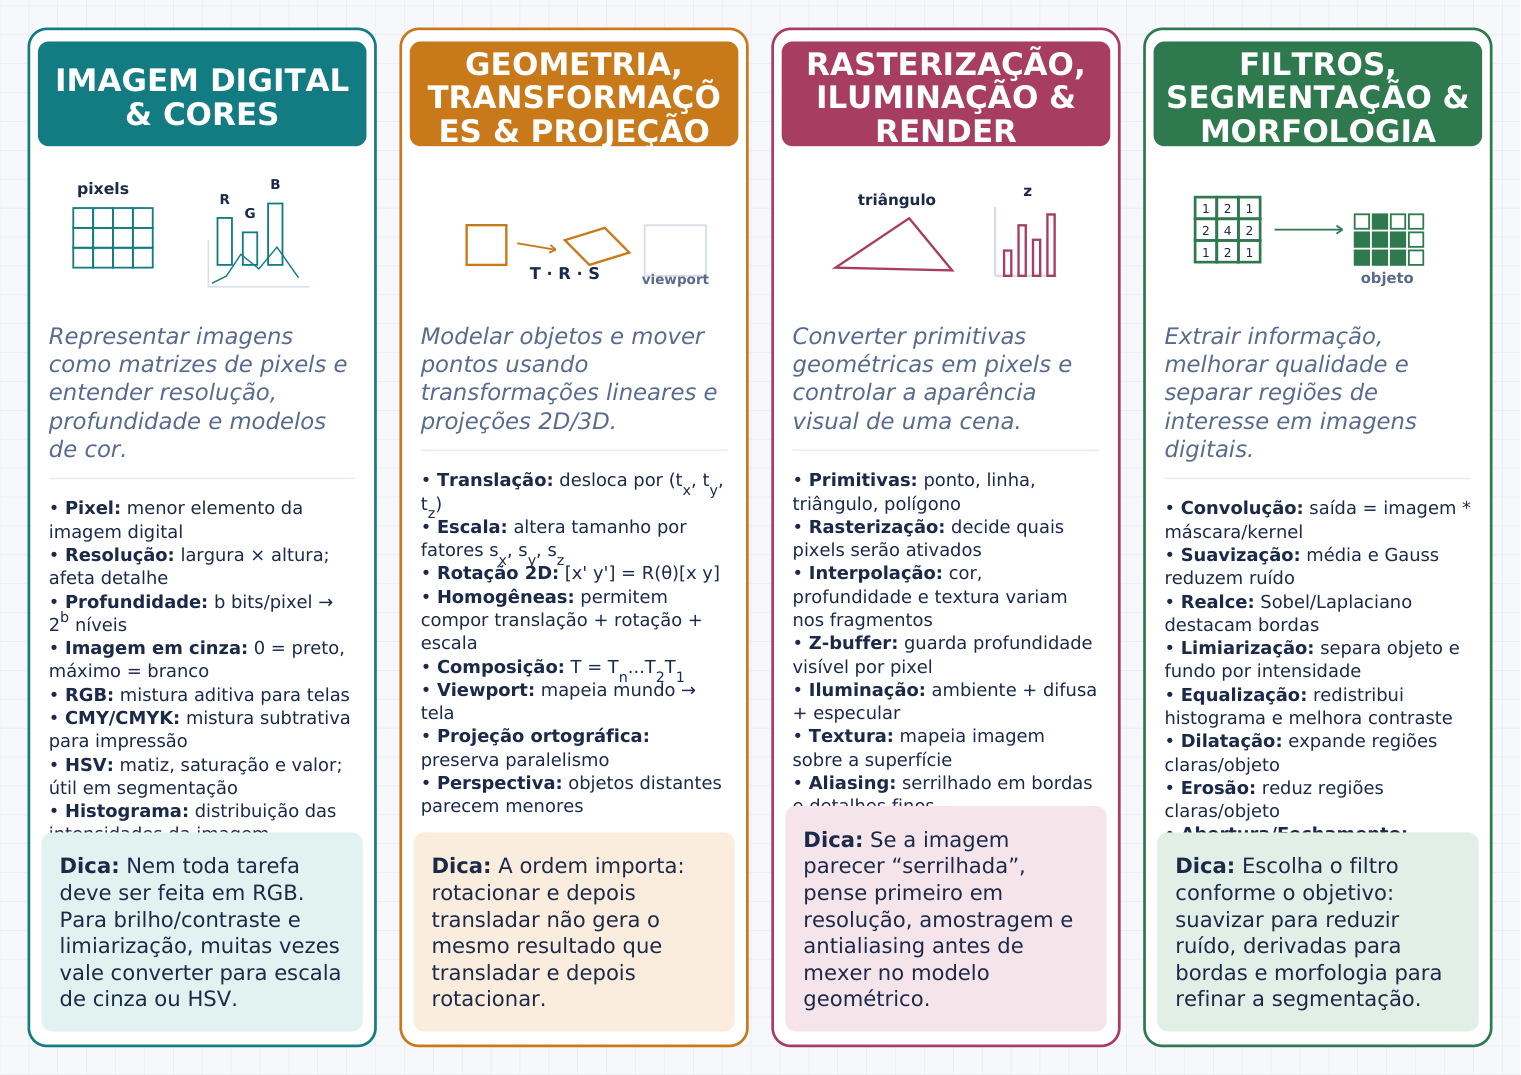

In [2]:
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Computacao_Grafica_Processamento_Imagens.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


1) IMAGEM DIGITAL: matriz 4x4 em tons de cinza
[[  0  60 120 180]
 [ 60 120 180 240]
 [120 180 240 255]
 [180 240 255 255]]

2) TRANSFORMACAO 2D: rotacao de 30 graus (matriz homogenea)
   R(30) * (1,0) = [0.866 0.5  ]
   (a ordem das transformacoes importa: R*T != T*R)

3) CONVOLUCAO - filtro de suavizacao (media 3x3)


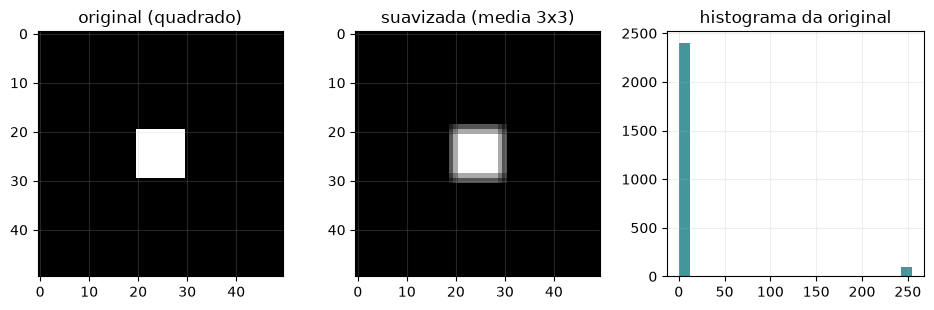


4) DETECCAO DE BORDAS - Sobel


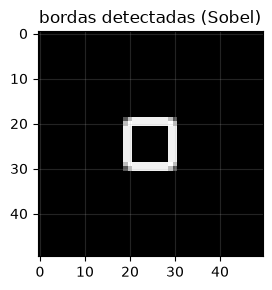


5) LIMIARIZACAO (segmentacao simples)
   pixels acima de 127: 100 (regiao do quadrado)

6) TRANSFORMACAO DE INTENSIDADE (negativo e equalizacao simples)


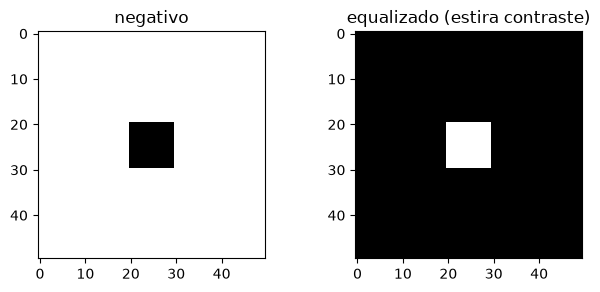


OK - graficos e processamento de imagem com NumPy.


In [3]:

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("1) IMAGEM DIGITAL: matriz 4x4 em tons de cinza")
img = np.array([[0, 60, 120, 180],
                [60, 120, 180, 240],
                [120, 180, 240, 255],
                [180, 240, 255, 255]], dtype=np.uint8)
print(img)

print("\n2) TRANSFORMACAO 2D: rotacao de 30 graus (matriz homogenea)")
theta = np.radians(30)
R = np.array([[np.cos(theta), -np.sin(theta), 0],
              [np.sin(theta),  np.cos(theta), 0],
              [0, 0, 1]])
p = np.array([1, 0, 1])   # ponto (1,0) homogeneo
print("   R(30) * (1,0) =", (R @ p)[:2].round(3))
print("   (a ordem das transformacoes importa: R*T != T*R)")

print("\n3) CONVOLUCAO - filtro de suavizacao (media 3x3)")
im = np.zeros((50, 50)); im[20:30, 20:30] = 255
kernel = np.ones((3, 3))/9
def conv2d(a, k):
    out = np.zeros_like(a)
    p = k.shape[0]//2
    for i in range(p, a.shape[0]-p):
        for j in range(p, a.shape[1]-p):
            out[i, j] = (a[i-p:i+p+1, j-p:j+p+1]*k).sum()
    return out
suave = conv2d(im, kernel)

fig, ax = plt.subplots(1, 3, figsize=(9.5, 3.2))
ax[0].imshow(im, cmap="gray"); ax[0].set_title("original (quadrado)")
ax[1].imshow(suave, cmap="gray"); ax[1].set_title("suavizada (media 3x3)")
ax[2].hist(im.ravel(), bins=20, color="#147D82", alpha=.8)
ax[2].set_title("histograma da original")
for a in ax: a.grid(alpha=.2)
plt.tight_layout(); plt.show()

print("\n4) DETECCAO DE BORDAS - Sobel")
gx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
gy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
fx = conv2d(im, gx); fy = conv2d(im, gy)
borda = np.sqrt(fx**2 + fy**2)
plt.figure(figsize=(6, 3))
plt.imshow(borda, cmap="gray"); plt.title("bordas detectadas (Sobel)")
plt.grid(alpha=.2); plt.tight_layout(); plt.show()

print("\n5) LIMIARIZACAO (segmentacao simples)")
limiar = 127
mask = (im > limiar).astype(int)
print(f"   pixels acima de {limiar}: {mask.sum()} (regiao do quadrado)")

print("\n6) TRANSFORMACAO DE INTENSIDADE (negativo e equalizacao simples)")
neg = 255 - im
eq = np.interp(im, (im.min(), im.max()), (0, 255)).astype(np.uint8)
fig2, ax2 = plt.subplots(1, 2, figsize=(6.5, 3))
ax2[0].imshow(neg, cmap="gray"); ax2[0].set_title("negativo")
ax2[1].imshow(eq, cmap="gray"); ax2[1].set_title("equalizado (estira contraste)")
plt.tight_layout(); plt.show()
print("\nOK - graficos e processamento de imagem com NumPy.")


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
